# Lab 10: Small-World Networks, Path Length, and Clustering

In this lab, you will study two important network statistics:

- average path length,
- clustering.

A graph is often called “small-world” if it combines:
- relatively short path lengths,
- relatively high clustering.

But this raises an important question:

**Compared to what?**

In this lab, you will compare real and hand-built graphs to standard random graph models. Your goal is not just to compute statistics, but to decide whether the observed values look ordinary or unusual relative to a model.

This is one of the first steps toward statistical thinking in network science.

In [1]:
from lab10_helpers import *
import networkx as nx

### Part 1: Warm-up — path length and clustering in familiar graphs

Before studying a real network, compare a few familiar graph families.

In [2]:
# Set a global number of nodes on par with Zachary's karate club
N_NODES = 34

In [3]:
P = path_graph(N_NODES)
C = cycle_graph(N_NODES)
S = star_graph(N_NODES)
R = random_graph(N_NODES, 38, seed=10)

In [4]:
# Helper for nicer printing
def pprint(d, indent=0, visited=None):
   if visited is None:
       visited = set()
   for key, value in d.items():
       print(" " * indent + str(key) + ":")
       if isinstance(value, dict):
           if id(value) in visited:
               print(" " * (indent + 4) + "{...} (recursive reference)")
           else:
               visited.add(id(value))
               pretty_print_dict(value, indent + 4, visited)
       else:
           print(" " * (indent + 4) + str(value))


In [5]:
print("****** Path graph metrics ******")
pprint(graph_metrics(P))
print("****** Cycle graph metrics ******")
pprint(graph_metrics(C))
print("****** Star graph metrics ******")
pprint(graph_metrics(S))
print("****** Random graph metrics ******")
pprint(graph_metrics(R))

****** Path graph metrics ******
nodes:
    34
edges:
    33
largest_component_nodes:
    34
average_path_length:
    11.666666666666666
average_clustering:
    0.0
transitivity:
    0
density:
    0.058823529411764705
****** Cycle graph metrics ******
nodes:
    34
edges:
    34
largest_component_nodes:
    34
average_path_length:
    8.757575757575758
average_clustering:
    0.0
transitivity:
    0
density:
    0.06060606060606061
****** Star graph metrics ******
nodes:
    34
edges:
    33
largest_component_nodes:
    34
average_path_length:
    1.9411764705882353
average_clustering:
    0.0
transitivity:
    0
density:
    0.058823529411764705
****** Random graph metrics ******
nodes:
    34
edges:
    38
largest_component_nodes:
    28
average_path_length:
    3.6666666666666665
average_clustering:
    0.10784313725490195
transitivity:
    0.11842105263157894
density:
    0.0677361853832442


Questions:
- Which graph has the largest average path length?
- Which graph has the smallest average path length?
- Which graph has the largest clustering?
- Which graph has the smallest clustering?
- Which graph feels most “small-world-like” at first glance?

### Part 2: Measure a real network

Now compute the same statistics for Zachary’s Karate Club graph.

In [6]:
K = karate_graph()
pprint(graph_metrics(K))

nodes:
    34
edges:
    78
largest_component_nodes:
    34
average_path_length:
    2.408199643493761
average_clustering:
    0.5706384782076823
transitivity:
    0.2556818181818182
density:
    0.13903743315508021


Questions:
- Is the graph connected?
- Does the average path length seem large or small, with respect to the reference graphs?
- Does the clustering seem large or small, with respect to the reference graphs?

### Part 3: Compared to what?

A network statistic by itself does not mean much unless we compare it to a model.
Here is where things start to become really exciting!

We will compare the karate club graph to a family of random graphs with the same number of vertices and edges.
The reference family we will be using is the *Erdős–Rényi* model.
We have previously seen $G(n,m)$ as a graph that is chosen uniformly at random from the collection of all graphs that have $n$ nodes and $m$ edges.

Another family is $G(n,p)$, where the graph is constructed by connecting nodes randomly. Each edge is included in the graph with a probability $p$, independently from every other edge. This model is also known as the binomial model.

As in statistics, we can't depend on single point estimates to devive meaningful conclusions. 
Recall: *the sample size $N$ matters*; the typical rule of thumb is $N=30$.
What this translates to for our graph statistics is we will generate 30 random graphs (adding variability by setting different seeds for each "experiment").
We will call this experimentation a *simulation* of the graph, and using these simulations, we can compare our real world graph.

In [7]:
comparison = compare_observed_to_simulation(K, trials=30, seed=10)
comparison["observed"]

{'nodes': 34,
 'edges': 78,
 'largest_component_nodes': 34,
 'average_path_length': 2.408199643493761,
 'average_clustering': 0.5706384782076823,
 'transitivity': 0.2556818181818182,
 'density': 0.13903743315508021}

In the above call, the simulation function returns a dictionary with four keys:
- 'observed': the real world graph we observed (dictionary of its summary metrics)
- 'simulated_path_lengths': a list of the path lengths for our 30 trials
- 'simulated_clusterings': a list of the average clustering for our 30 trials
- 'simulated_transitivity': a list of the transitivity value for our 30 trials

The helper function has an additional 'summarize_simulation' that we can use to aggregate the values into typical statistical measures (mean, median, min, max, standard deviation).

In [8]:
summarize_simulation(comparison['simulated_path_lengths'])

{'mean': 2.3866124000920017,
 'median': 2.3868092691622103,
 'min': 2.1913978494623656,
 'max': 2.570409982174688,
 'stdev': 0.06966513222182046}

In [9]:
summarize_simulation(comparison['simulated_clusterings'])

{'mean': 0.11883825325001796,
 'median': 0.12238562091503268,
 'min': 0.04551820728291317,
 'max': 0.18828197945845004,
 'stdev': 0.03445189200174683}

In [10]:
summarize_simulation(comparison['simulated_transitivity'])

{'mean': 0.1229402148564303,
 'median': 0.12241160615189473,
 'min': 0.04643962848297214,
 'max': 0.18018018018018017,
 'stdev': 0.02868951954426333}

Questions:
- Is the observed average path length close to the simulated values, or far away?
- Is the observed clustering close to the simulated values, or far away?
- Which statistic looks more unusual relative to the model?

### Part 4: Visualizing observed vs simulated values

A list of simulated numbers is useful, but a plot makes the comparison clearer.

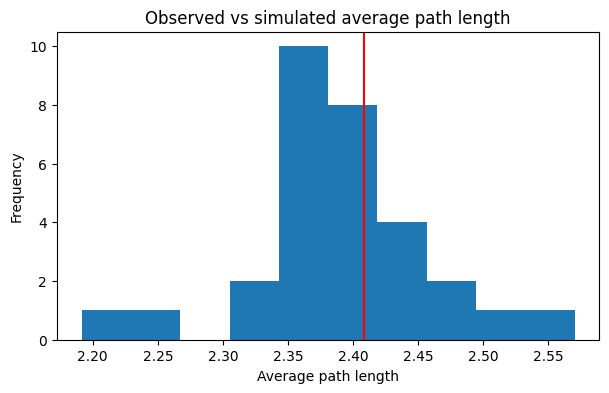

In [11]:
plot_metric_comparison(
    comparison["simulated_path_lengths"],
    comparison["observed"]["average_path_length"],
    xlabel="Average path length",
    title="Observed vs simulated average path length"
)

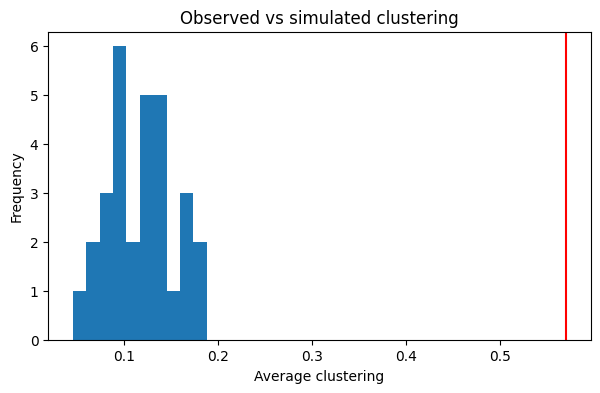

In [12]:
plot_metric_comparison(
    comparison["simulated_clusterings"],
    comparison["observed"]["average_clustering"],
    xlabel="Average clustering",
    title="Observed vs simulated clustering"
)

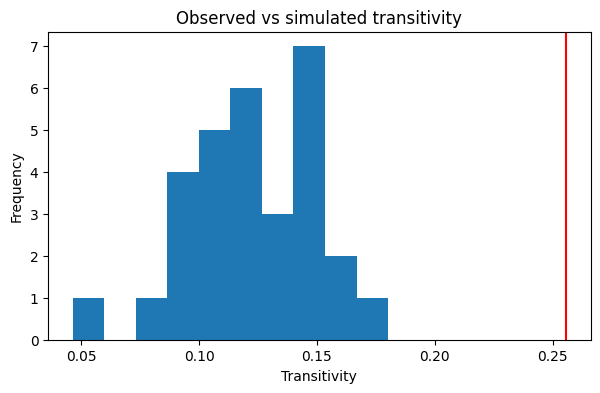

In [13]:
plot_metric_comparison(
    comparison["simulated_transitivity"],
    comparison["observed"]["transitivity"],
    xlabel="Transitivity",
    title="Observed vs simulated transitivity"
)

Questions:
- Does the observed path length look typical or unusual?
- Does the observed clustering look typical or unusual?
- Does the karate club graph look more clustered than a random graph with the same size?
- Is that enough to justify calling it “small-world-like”?

### Part 5: Why simulate many times?

If you only compare the observed graph to one random graph, your conclusion may depend too much on chance.

This is why repeated simulation matters. Let's see an example of such a failure.

In [15]:
single_random = er_graph_matching_observed(K, seed=123)
graph_metrics(single_random)

{'nodes': 34,
 'edges': 78,
 'largest_component_nodes': 34,
 'average_path_length': 2.4206773618538326,
 'average_clustering': 0.11615312791783379,
 'transitivity': 0.14825581395348839,
 'density': 0.13903743315508021}

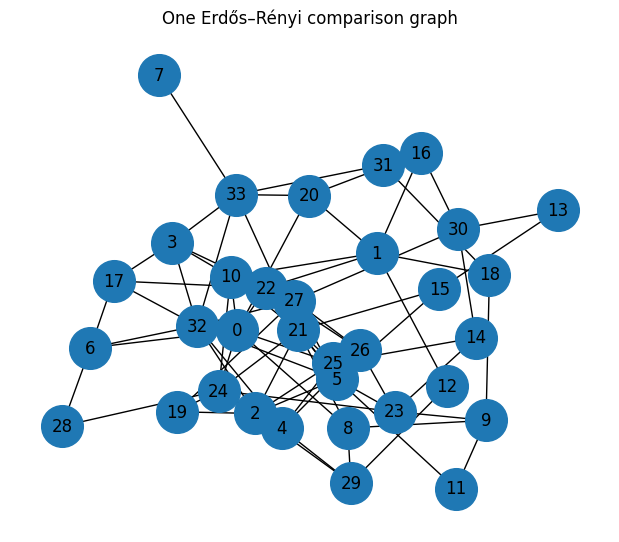

In [16]:
draw_graph(single_random, "One Erdős–Rényi comparison graph")

Question:
- even though this is a 'random' graph, how does it compare to Zachary's karate club?

### Part 6: A second observed graph

Now try the same workflow on *TWO* other graphs.

1) The first graph (call it G2 for simplicity) can be modelled from the family of *Watts-Strogatz* random graphs.This family is designed to more closely mirror small-world phenomenon (high clustering and short average path lengths) than ER-random graphs. The analogy here to basic statistics is knowing what distribution to test against. You wouldn't baseline using a normal curve if you knew the data you were looking as was extremely heavy-tailed, as hypotheses would constantly reject.
Same goes for graphs: if we're looking to show deviation from a small-world phenomenon (or show a graph looks approximately small-world), we should choose the right baseline model.

The Watts-Strogatz model builds a graph by beginning with a lattice, then re-wiring some of the connections to take 'short-cuts' across the lattice, mimicing connections that being groups of friends together (hence decreasing average path lengths). NetworkX will be the engine for creating such graphs.

2) Construct your own graph (call it G3) and run the same workflow. Take note of the design principles you used to create the graph and what kind of behavior it may serve to model in the real world.


In [ ]:
# TODO: your code and experiments here

## Reflection Questions

1. What does average path length measure?
2. What does clustering measure?
3. Why does a single observed value mean little without comparison?
4. Why is it useful to simulate many random graphs instead of just one?
5. In your experiments, which statistic looked more unusual for the observed graph: path length or clustering?
6. Why does this lab begin to resemble statistical testing?
7. What would stronger evidence look like if you wanted to argue that a graph is unusually clustered?
8. What question from this lab feels like the beginning of a research problem?